SMOTE(Synthetic Minority Over-sampling Technique) is a technique used to address class imbalance in datasets. It works by creating synthetic samples of the minority class to balance the dataset. SMOTE generates new samples by interpolating between existing minority class samples, which helps to improve the performance of machine learning models trained on imbalanced data.


In [1]:
##make_classification - Generate a random n-class classification problem.

from sklearn.datasets import  make_classification

In [3]:
# n_samples: The number of samples.
## n_redundant: The number of redundant features. These features are generated as random linear combinations of the informative features.
## n_features: The total number of features. These include informative, redundant, and repeated features.
## n_clusters_per_class: The number of clusters per class. Each class is composed of one or more clusters.
## weights: The proportions of samples assigned to each class. If not provided, classes are balanced. 

## weights=[0.90] means that 90% of the samples belong to one class and the remaining 10% belong to the other class, creating an imbalanced dataset. This is often used to simulate real-world scenarios where one class is more prevalent than the other, which can be useful for testing the performance of classification algorithms on imbalanced data.   






x,y=make_classification(n_samples=1000,n_redundant=0, n_features=2, n_clusters_per_class=1, weights=[0.90], random_state=12)  


In [8]:

## The make_classification function generates a synthetic dataset for classification tasks. In this case, it creates a dataset with 1000 samples, 2 features, and an imbalanced class distribution where 90% of the samples belong to one class and 10% belong to the other class. The random_state parameter ensures that the dataset can be reproduced in future runs.

## f1 and f2 are the two features generated by make_classification, and target is the class label (0 or 1) for each sample. The resulting dataset is stored in a pandas DataFrame called final_df, which combines the features and the target variable for easy analysis and modeling.  

## df1 is a DataFrame containing the features f1 and f2, while df2 is a DataFrame containing the target variable. The pd.concat function is used to concatenate these two DataFrames along the columns (axis=1) to create a final DataFrame that includes both the features and the target variable. The final_df.head() function displays the first few rows of the resulting DataFrame for verification.







import pandas as pd
df1=pd.DataFrame(x,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
final_df=pd.concat([df1,df2],axis=1)
final_df.head()



,f1,f2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


In [9]:
## The value_counts() function is used to count the occurrences of each unique value in the 'target' column of the final_df DataFrame. This is particularly useful for understanding the distribution of classes in the dataset, especially in cases where there is class imbalance. In this context, it will show how many samples belong to each class (0 and 1) in the target variable, confirming the imbalanced nature of the dataset created with make_classification.  


final_df['target'].value_counts()


target
0    900
1    100
Name: count, dtype: int64

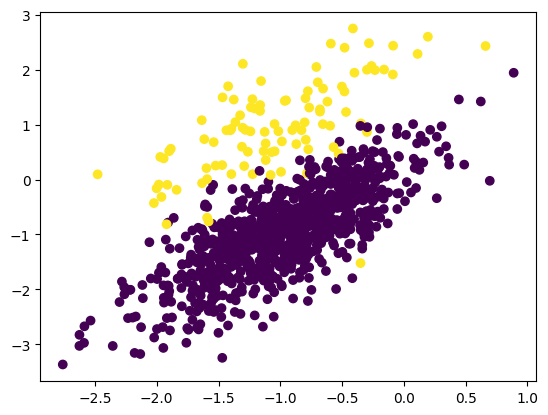

In [11]:
## The scatter plot created by plt.scatter() visualizes the relationship between the two features (f1 and f2) in the dataset, with points colored according to their class labels (target). This allows us to visually assess the distribution of the classes and how well they are separated in the feature space. In this case, we can see that the majority of points belong to one class (likely represented by one color), while a smaller number of points belong to the other class, illustrating the imbalanced nature of the dataset.  


import matplotlib.pyplot as plt
plt.scatter(final_df['f1'],final_df['f2'],c=final_df['target'])

In [12]:
## in order to apply smote we have to install imblearn library using pip install imblearn
from imblearn.over_sampling import SMOTE


In [13]:
## transfer the data set
# x,y=oversample.fit_resample(final_df[['f1','f2']],final_df['target']) = 

##  fit_resample() is a method provided by the SMOTE class in the imblearn library. It takes the features (in this case, 'f1' and 'f2') and the target variable ('target') as input and applies the SMOTE algorithm to generate synthetic samples for the minority class. The resulting balanced dataset is returned as x (features) and y (target variable), which can then be used for training machine learning models. This process helps to address class imbalance by creating new samples for the underrepresented class, improving the performance of classifiers on imbalanced datasets.




oversample=SMOTE()
x,y=oversample.fit_resample(final_df[['f1','f2']],final_df['target'])




In [14]:
## After applying SMOTE, the shape of the feature matrix x will show that the number of samples has increased, particularly for the minority class, resulting in a balanced dataset. The number of features will remain the same (2 in this case), but the number of samples will be equal for both classes, which can be confirmed by checking the shape of x.




x.shape

(1800, 2)

In [15]:
## After applying SMOTE, the distribution of classes in the target variable y will be balanced, meaning that there will be an equal number of samples for each class (0 and 1). The len(y[y==0]) will give the count of samples belonging to class 0, and len(y[y==1]) will give the count of samples belonging to class 1. Since SMOTE generates synthetic samples for the minority class, both counts should be equal, confirming that the dataset is now balanced. 




len(y[y==0]),len(y[y==1])


(900, 900)

In [16]:
## over_sample_df is a new DataFrame created by concatenating the features (f1 and f2) and the target variable (target) after applying SMOTE. This DataFrame contains the balanced dataset, which can be used for further analysis or modeling. The pd.concat function is used to combine the feature DataFrame (df1) and the target DataFrame (df2) along the columns (axis=1), resulting in a single DataFrame that includes both the features and the target variable.


df1=pd.DataFrame(x,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
oversample_df=pd.concat([df1,df2],axis=1)




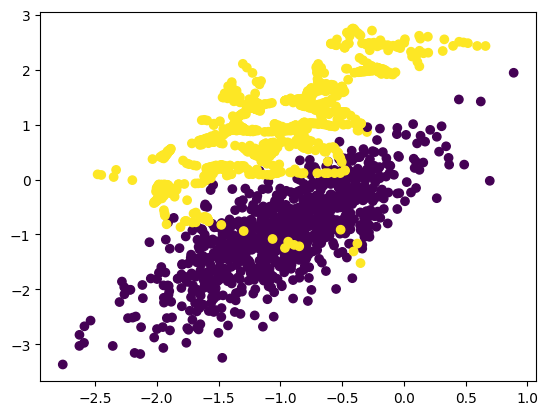

In [ ]:
## 



plt.scatter(oversample_df['f1'],oversample_df['f2'],c=oversample_df['target'])

